In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv('creditcard.csv')

print(df.shape)
print(df.head())
print(df['Class'].value_counts())


Saving creditcard.csv to creditcard.csv
(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.

In [ ]:
print(df.isnull().sum().sum())  # should print 0
print(df.dtypes)
print(df['Amount'].describe())

0
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# scale Amount and Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# drop the original unscaled columns
df = df.drop(columns=['Amount', 'Time'])

# separate features and label
X = df.drop(columns=['Class'])
y = df['Class']

# split 80% train, 20% test — stratified keeps the fraud ratio the same in both
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Fraud in training set:", y_train.sum())
print("Fraud in test set:", y_test.sum())

Training set size: (227845, 30)
Test set size: (56962, 30)
Fraud in training set: 394
Fraud in test set: 98


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import numpy as np

# version 1 — no resampling (baseline)
X_train_none = X_train.copy()
y_train_none = y_train.copy()

# version 2 — SMOTE (creates synthetic fraud examples)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# version 3 — undersampling (reduces legitimate transactions)
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# check the class balance in each
print("No resampling:", np.bincount(y_train_none))
print("SMOTE:", np.bincount(y_train_smote))
print("Undersampling:", np.bincount(y_train_under))

No resampling: [227451    394]
SMOTE: [227451 227451]
Undersampling: [394 394]


In [ ]:
import pandas as pd

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Files saved!")

Files saved!


/tmp/ipykernel_2132/4169678276.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([legit_amounts, fraud_amounts], labels=['Legitimate', 'Fraud'])


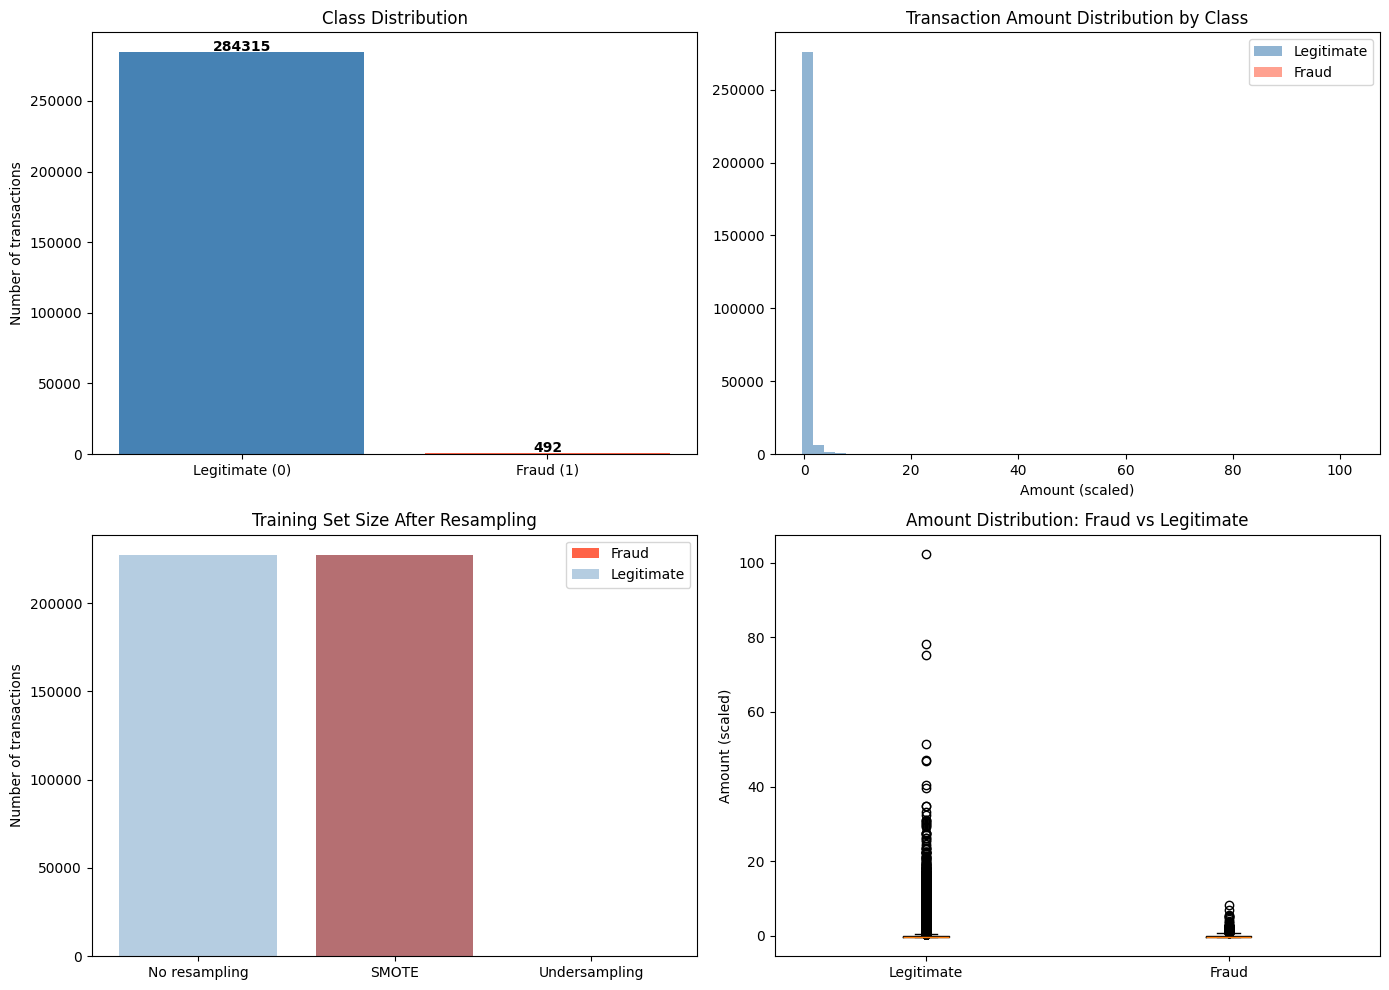

Saved as eda_plots.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# plot 1 — class imbalance
axes[0,0].bar(['Legitimate (0)', 'Fraud (1)'],
              [284315, 492],
              color=['steelblue', 'tomato'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Number of transactions')
for i, v in enumerate([284315, 492]):
    axes[0,0].text(i, v + 1000, str(v), ha='center', fontweight='bold')

# plot 2 — transaction amount by class
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]
axes[0,1].hist(legit['Amount_scaled'], bins=50, alpha=0.6, label='Legitimate', color='steelblue')
axes[0,1].hist(fraud['Amount_scaled'], bins=50, alpha=0.6, label='Fraud', color='tomato')
axes[0,1].set_title('Transaction Amount Distribution by Class')
axes[0,1].set_xlabel('Amount (scaled)')
axes[0,1].legend()

# plot 3 — resampling comparison
axes[1,0].bar(['No resampling', 'SMOTE', 'Undersampling'],
              [394, 227451, 394],
              color='tomato', label='Fraud')
axes[1,0].bar(['No resampling', 'SMOTE', 'Undersampling'],
              [227451, 227451, 394],
              bottom=[0, 0, 0],
              color='steelblue', alpha=0.4, label='Legitimate')
axes[1,0].set_title('Training Set Size After Resampling')
axes[1,0].set_ylabel('Number of transactions')
axes[1,0].legend()

# plot 4 — fraud amount vs legitimate amount boxplot
df_plot = df[['Amount_scaled', 'Class']].copy()
df_plot['Class'] = df_plot['Class'].map({0: 'Legitimate', 1: 'Fraud'})
fraud_amounts = df[df['Class']==1]['Amount_scaled']
legit_amounts = df[df['Class']==0]['Amount_scaled']
axes[1,1].boxplot([legit_amounts, fraud_amounts], labels=['Legitimate', 'Fraud'])
axes[1,1].set_title('Amount Distribution: Fraud vs Legitimate')
axes[1,1].set_ylabel('Amount (scaled)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as eda_plots.png")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# train on no resampling first
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_none, y_train_none)

# predict on test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# print results
print("=== Random Forest — No Resampling ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("AUC-PR:", round(average_precision_score(y_test, y_prob), 4))

=== Random Forest — No Resampling ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9581
AUC-PR: 0.8653


In [ ]:
rf_smote = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

print("=== Random Forest — SMOTE ===")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_smote), 4))
print("AUC-PR:", round(average_precision_score(y_test, y_prob_smote), 4))

=== Random Forest — SMOTE ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9688
AUC-PR: 0.8675


In [ ]:
rf_under = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_under.fit(X_train_under, y_train_under)

y_pred_under = rf_under.predict(X_test)
y_prob_under = rf_under.predict_proba(X_test)[:, 1]

print("=== Random Forest — Undersampling ===")
print(classification_report(y_test, y_pred_under))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_under), 4))
print("AUC-PR:", round(average_precision_score(y_test, y_prob_under), 4))

=== Random Forest — Undersampling ===
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.91      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962

ROC-AUC: 0.9782
AUC-PR: 0.701


In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2]
}

rf_tuned = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    rf_tuned,
    param_grid,
    scoring='average_precision',  # optimise for AUC-PR
    cv=3,                          # 3-fold cross validation
    n_jobs=-1,                     # use all CPU cores
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation AUC-PR:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import GridSearchCV

# smaller grid — fewer combinations
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
}

rf_tuned = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    rf_tuned,
    param_grid,
    scoring='average_precision',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# use no-resampling data — much smaller (227k rows instead of 450k)
grid_search.fit(X_train_none, y_train_none)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation AUC-PR:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 4 candidates, totalling 12 fits


KeyboardInterrupt: 

In [ ]:
# manually test 4 configurations
configs = [
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 20},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': 20},
]

best_aucpr = 0
best_config = None

for config in configs:
    rf = RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        **config
    )
    rf.fit(X_train_none, y_train_none)
    y_prob = rf.predict_proba(X_test)[:, 1]
    aucpr = round(average_precision_score(y_test, y_prob), 4)
    print(f"n_estimators={config['n_estimators']}, max_depth={config['max_depth']} → AUC-PR: {aucpr}")

    if aucpr > best_aucpr:
        best_aucpr = aucpr
        best_config = config

print("\nBest config:", best_config)
print("Best AUC-PR:", best_aucpr)

n_estimators=100, max_depth=10 → AUC-PR: 0.8253
n_estimators=100, max_depth=20 → AUC-PR: 0.8522
n_estimators=200, max_depth=10 → AUC-PR: 0.8203
n_estimators=200, max_depth=20 → AUC-PR: 0.8521

Best config: {'n_estimators': 100, 'max_depth': 20}
Best AUC-PR: 0.8522


In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.0017, random_state=42)

iso_forest.fit(X_train_none)

# predict — Isolation Forest returns -1 for anomaly, 1 for normal

y_pred_iso = iso_forest.predict(X_test)

y_pred_iso = (y_pred_iso == -1).astype(int)  # convert to 0/1

print("=== Isolation Forest ===")

print(classification_report(y_test, y_pred_iso))

print("AUC-PR:", round(average_precision_score(y_test, iso_forest.score_samples(X_test) * -1), 4))


=== Isolation Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.31      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962

AUC-PR: 0.1916


In [ ]:
from sklearn.svm import OneClassSVM

# use a sample for training — One-Class SVM is very slow on large datasets
from sklearn.utils import resample
X_train_sample = resample(X_train_none, n_samples=10000, random_state=42)

ocsvm = OneClassSVM(nu=0.0017, kernel='rbf', gamma='auto')
ocsvm.fit(X_train_sample)

y_pred_svm = ocsvm.predict(X_test)
y_pred_svm = (y_pred_svm == -1).astype(int)

print("=== One-Class SVM ===")
print(classification_report(y_test, y_pred_svm))
print("AUC-PR:", round(average_precision_score(y_test, ocsvm.score_samples(X_test) * -1), 4))

=== One-Class SVM ===
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.03      0.87      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.91      0.52     56962
weighted avg       1.00      0.96      0.98     56962

AUC-PR: 0.1625


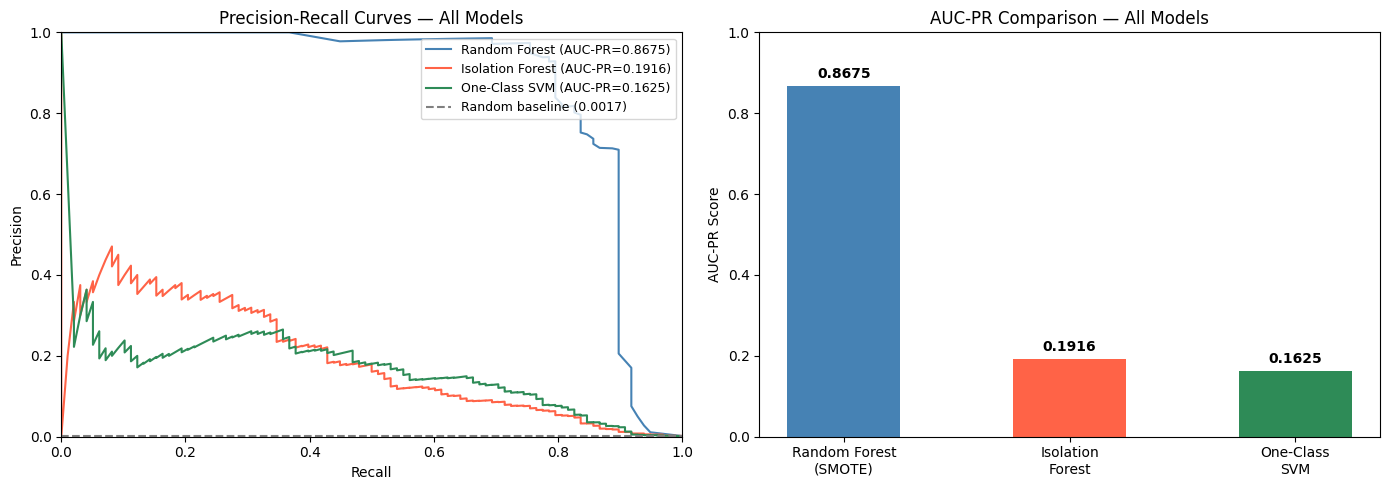

Saved as model_comparison.png


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve

# get precision-recall curves for each model
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_smote)
precision_iso, recall_iso, _ = precision_recall_curve(y_test, iso_forest.score_samples(X_test) * -1)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, ocsvm.score_samples(X_test) * -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1 — precision recall curves
axes[0].plot(recall_rf, precision_rf, color='steelblue', label=f'Random Forest (AUC-PR=0.8675)')
axes[0].plot(recall_iso, precision_iso, color='tomato', label=f'Isolation Forest (AUC-PR=0.1916)')
axes[0].plot(recall_svm, precision_svm, color='seagreen', label=f'One-Class SVM (AUC-PR=0.1625)')
axes[0].axhline(y=0.0017, color='gray', linestyle='--', label='Random baseline (0.0017)')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves — All Models')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# plot 2 — AUC-PR bar chart (fixed)
models = ['Random Forest\n(SMOTE)', 'Isolation\nForest', 'One-Class\nSVM']
aucpr_scores = [0.8675, 0.1916, 0.1625]
colors = ['steelblue', 'tomato', 'seagreen']

axes[1].bar(models, aucpr_scores, color=colors, width=0.5)
axes[1].set_title('AUC-PR Comparison — All Models')
axes[1].set_ylabel('AUC-PR Score')
axes[1].set_ylim([0, 1])

for i, score in enumerate(aucpr_scores):
    axes[1].text(i, score + 0.02, str(score), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as model_comparison.png")